In [1]:
import os
import glob
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
print("imported all")

imported all


In [2]:
# --- Load Parquet Files ---
def load_parquet_files(data_dir, files_to_load=8):
    parquet_files = sorted(glob.glob(os.path.join(data_dir, "*.parquet")))
    assert len(parquet_files) >= files_to_load, "Not enough .parquet files found."
    data_chunks = []
    for file in parquet_files[:files_to_load]:
        print(f"Loading: {os.path.basename(file)}")
        pf = pd.read_parquet(file, engine="pyarrow")
        for col in pf.select_dtypes('number').columns:
            if 'int' in str(pf[col].dtype):
                pf[col] = pd.to_numeric(pf[col], downcast='integer')
            elif 'float' in str(pf[col].dtype):
                pf[col] = pd.to_numeric(pf[col], downcast='float')
        for col in pf.select_dtypes('object').columns:
            if pf[col].nunique() < 0.5 * len(pf):
                pf[col] = pf[col].astype('category')
        data_chunks.append(pf)
        gc.collect()
    df = pd.concat(data_chunks, ignore_index=True)
    return df

DATA_DIR = r"C:\Users\MY PC\OneDrive\Desktop\self-healing-cybersecurity-framework\data"

print("\n# Loading data efficiently from Parquet files...")
df = load_parquet_files(DATA_DIR, files_to_load=8)
print(f"Loaded dataframe shape: {df.shape}")



# Loading data efficiently from Parquet files...
Loading: Benign-Monday-no-metadata.parquet
Loading: Botnet-Friday-no-metadata.parquet
Loading: Bruteforce-Tuesday-no-metadata.parquet
Loading: DDoS-Friday-no-metadata.parquet
Loading: DoS-Wednesday-no-metadata.parquet
Loading: Infiltration-Thursday-no-metadata.parquet
Loading: NUSW-NB15_GT.CSV.parquet
Loading: Portscan-Friday-no-metadata.parquet
Loaded dataframe shape: (2332337, 89)


In [3]:
# --- Data Cleaning ---
drop_cols = [
    'Flow ID', 'Src IP', 'Dst IP', 'Dst Port', 'Timestamp', 'Source IP',
    'Destination IP', 'Fwd Header Length.1', 'Start time', 'Last time',
    'Attack Name', 'Attack Reference', '.', 'Attack category', 'Attack subcategory',
    'Source Port', 'Destination Port'
]

df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors='ignore')

if 'Label' in df.columns:
    df['Label'] = df['Label'].astype(str).str.strip().str.upper()
else:
    df['Label'] = 'BENIGN'  # Default to benign if no Label column

print("\nLabel distribution after cleaning:")
print(df['Label'].value_counts())



Label distribution after cleaning:
Label
BENIGN              1823641
NAN                  174347
DOS HULK             172846
DDOS                 128014
DOS GOLDENEYE         10286
FTP-PATATOR            5931
DOS SLOWLORIS          5385
DOS SLOWHTTPTEST       5228
SSH-PATATOR            3219
PORTSCAN               1956
BOT                    1437
INFILTRATION             36
HEARTBLEED               11
Name: count, dtype: int64


In [4]:
# --- Split Data for Supervised and Unsupervised ---
benign_data = df[df['Label'] == 'BENIGN'].copy()
attack_data = df[df['Label'] != 'BENIGN'].copy()

supervised_df = pd.concat([benign_data.sample(frac=0.3, random_state=42), attack_data], axis=0)
unsupervised_df = benign_data.drop(supervised_df.index, errors='ignore')

y_supervised = supervised_df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1).values
X_supervised = supervised_df.drop(columns=['Label'])
X_unsupervised = unsupervised_df.drop(columns=['Label'])

# Convert object columns to numeric
for df_part in [X_supervised, X_unsupervised]:
    for col in df_part.columns:
        if df_part[col].dtype == 'object':
            df_part[col] = pd.to_numeric(df_part[col], errors='coerce').fillna(0)

# Remove constant columns
const_cols = X_supervised.columns[X_supervised.nunique() <= 1]
X_supervised.drop(columns=const_cols, inplace=True)
X_unsupervised.drop(columns=const_cols, inplace=True)


In [5]:
X_supervised.fillna(0, inplace=True)
X_unsupervised.fillna(0, inplace=True)


In [6]:
# --- Feature Scaling ---
scaler = StandardScaler()
X_supervised_scaled = scaler.fit_transform(X_supervised)
X_unsupervised_scaled = scaler.transform(X_unsupervised.reindex(columns=X_supervised.columns, fill_value=0))

# --- Reshape for LSTM Autoencoder (1 timestep) ---
timesteps = 1
input_dim = X_supervised_scaled.shape[1]

X_supervised_lstm = X_supervised_scaled.reshape(-1, timesteps, input_dim)
X_unsupervised_lstm = X_unsupervised_scaled.reshape(-1, timesteps, input_dim)

print(f"Shapes: Supervised {X_supervised_lstm.shape}, Unsupervised {X_unsupervised_lstm.shape}")


Shapes: Supervised (1055788, 1, 69), Unsupervised (1276549, 1, 69)


In [7]:
# --- Define Hybrid Autoencoder Model ---
def build_hybrid_autoencoder(timesteps, input_dim, learning_rate=0.0001):
    inputs = Input(shape=(timesteps, input_dim))
    
    # LSTM encoder
    lstm_enc = LSTM(64, activation='relu', return_sequences=True)(inputs)
    lstm_enc = Dropout(0.2)(lstm_enc)
    lstm_enc = LSTM(32, activation='relu', return_sequences=False)(lstm_enc)
    lstm_enc = Dropout(0.2)(lstm_enc)
    
    # FNN encoder
    fnn_input = Flatten()(inputs)
    fnn_enc = Dense(64, activation='relu')(fnn_input)
    fnn_enc = Dropout(0.2)(fnn_enc)
    fnn_enc = Dense(32, activation='relu')(fnn_enc)
    
    # Concatenate encoded features
    concat = Concatenate()([lstm_enc, fnn_enc])
    
    # Decoder
    decoder = Dense(64, activation='relu')(concat)
    decoder = Dropout(0.2)(decoder)
    decoder_output = Dense(timesteps * input_dim, activation='linear')(decoder)
    decoder_reshaped = tf.keras.layers.Reshape((timesteps, input_dim))(decoder_output)
    
    model = Model(inputs, decoder_reshaped)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

In [8]:
# --- Train Autoencoder ---
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.0001

autoencoder = build_hybrid_autoencoder(timesteps, input_dim, LEARNING_RATE)
history = autoencoder.fit(
    X_unsupervised_lstm, X_unsupervised_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
3990/3990 [==============================] - 104s 24ms/step - loss: 7.5219 - val_loss: 0.3750
Epoch 2/20
3990/3990 [==============================] - 95s 24ms/step - loss: 6.7515 - val_loss: 0.3325
Epoch 3/20
3990/3990 [==============================] - 98s 25ms/step - loss: 5.6527 - val_loss: 0.3178
Epoch 4/20
3990/3990 [==============================] - 99s 25ms/step - loss: 5.5488 - val_loss: 0.3085
Epoch 5/20
3990/3990 [==============================] - 98s 25ms/step - loss: 4.1613 - val_loss: 0.3055
Epoch 6/20
3990/3990 [==============================] - 110s 27ms/step - loss: 4.3012 - val_loss: 0.2939
Epoch 7/20
3990/3990 [==============================] - 100s 25ms/step - loss: 3.6591 - val_loss: 0.2909
Epoch 8/20
3990/3990 [==============================] - 100s 25ms/step - loss: 3.0049 - val_loss: 0.2808
Epoch 9/20
3990/3990 [==============================] - 106s 27ms/step - loss: 3.0519 - val_loss: 0.2783
Epoch 10/20
3990/3990 [==============================] - 10

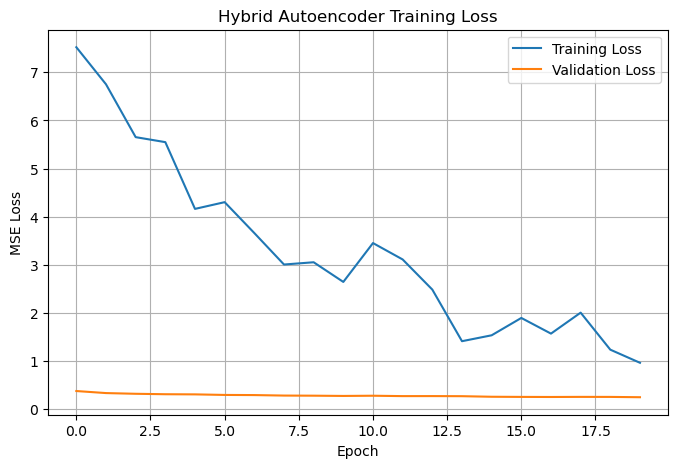

In [9]:

# --- Plot Loss ---
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hybrid Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

32994/32994 [==============================] - 90s 3ms/step


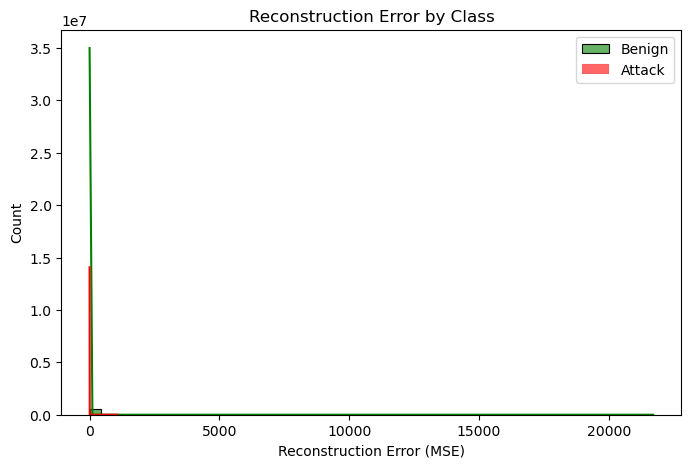

In [10]:
# --- Calculate Reconstruction Errors on Supervised Data ---
X_supervised_reconstructed = autoencoder.predict(X_supervised_lstm)
supervised_errors = np.mean(np.square(X_supervised_lstm - X_supervised_reconstructed), axis=(1,2))

# --- Plot Reconstruction Error Distribution ---
plt.figure(figsize=(8,5))
sns.histplot(supervised_errors[y_supervised == 0], color='green', bins=50, alpha=0.6, label='Benign', kde=True)
sns.histplot(supervised_errors[y_supervised == 1], color='red', bins=50, alpha=0.6, label='Attack', kde=True)
plt.title('Reconstruction Error by Class')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.show()


In [11]:
# Remove NaNs from supervised_errors and corresponding labels
mask = ~np.isnan(supervised_errors)
cleaned_errors = supervised_errors[mask]
cleaned_labels = y_supervised[mask]

auc = roc_auc_score(cleaned_labels, cleaned_errors)
print(f"ROC-AUC Score based on reconstruction error: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(cleaned_labels, cleaned_errors)


ROC-AUC Score based on reconstruction error: 0.9199


In [12]:
print(np.isnan(X_supervised_scaled).sum())  # Should be 0
print(np.isnan(X_unsupervised_scaled).sum()) # Should be 0


0
0


ROC-AUC Score based on reconstruction error: 0.9199


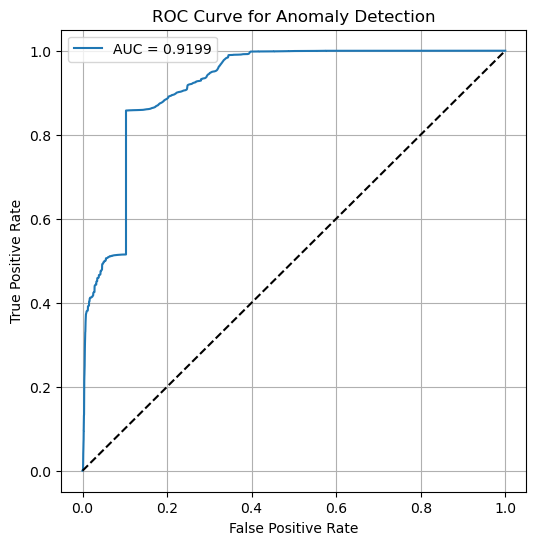

In [13]:
# --- ROC-AUC Evaluation ---
auc = roc_auc_score(y_supervised, supervised_errors)
print(f"ROC-AUC Score based on reconstruction error: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_supervised, supervised_errors)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.grid()
plt.show()

Optimal Threshold for anomaly detection: 0.068981


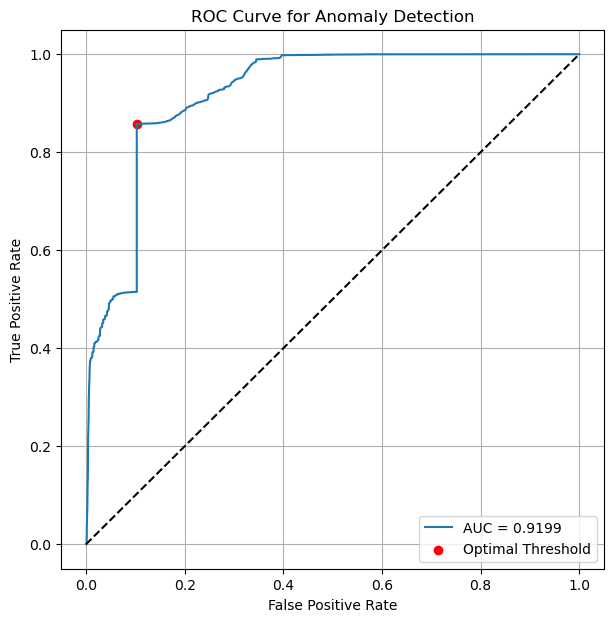

Average Precision Score: 0.9036


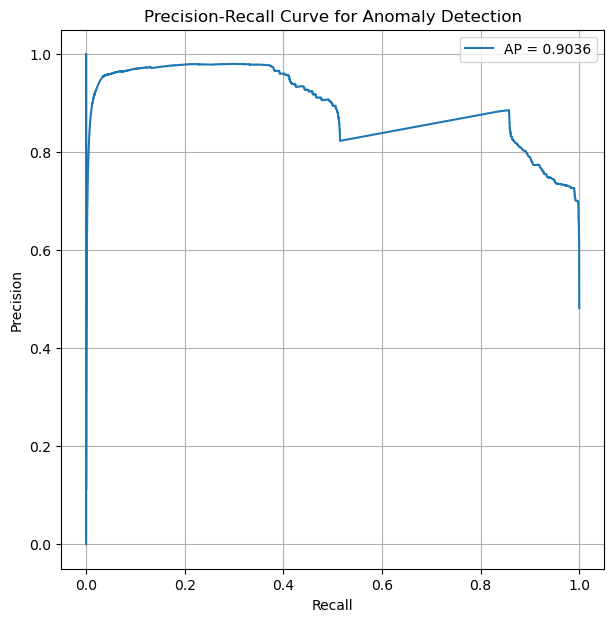

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Using existing fpr, tpr, thresholds from ROC curve
# Find optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold for anomaly detection: {optimal_threshold:.6f}")

# Plot ROC curve with threshold
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label='Optimal Threshold')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.grid(True)
plt.legend()
plt.show()

# Calculate Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(cleaned_labels, cleaned_errors)
ap_score = average_precision_score(cleaned_labels, cleaned_errors)
print(f'Average Precision Score: {ap_score:.4f}')

# Plot Precision-Recall Curve
plt.figure(figsize=(7,7))
plt.plot(recall, precision, label=f'AP = {ap_score:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
from cvss import CVSS3
from decimal import Decimal

manual_reference = {
    "DDOS": 9.8,
    "PORTSCAN": 3.2,
    "BOT": 9.9,
    "HEARTBLEED": 7.5,
    "BENIGN": 0.0,
    "UNKNOWN": 5.0
}

vector_reference = {
    "DDOS": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H",
    "PORTSCAN": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:L/I:N/A:N",
    "BOT": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:C/C:H/I:H/A:H",
    "HEARTBLEED": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N",
    "BENIGN": "CVSS:3.1/AV:L/AC:H/PR:H/UI:R/S:U/C:N/I:N/A:N",
    "UNKNOWN": "CVSS:3.1/AV:N/AC:H/PR:H/UI:R/S:C/C:L/I:L/A:L"
}

def compute_cvss_score(attack):
    manual = manual_reference.get(attack.upper(), 0.0)
    vector_str = vector_reference.get(attack.upper(), "")

    try:
        cvss = CVSS3(vector_str)
        vector = float(cvss.scores()[0])  # convert Decimal → float
        severity = cvss.severities()[0]
    except Exception as e:
        print(f"Error for {attack}: {e}")
        vector = 0.0
        severity = "ERROR"

    hybrid = round((manual + vector) / 2, 2)
    return {"Manual": manual, "Vector": vector, "Hybrid": hybrid, "Severity": severity}


In [16]:
attacks = ["DDOS", "PORTSCAN", "BOT", "HEARTBLEED", "BENIGN", "UNKNOWN"]

for attack in attacks:
    result = compute_cvss_score(attack)
    print(f"{attack} → {result}")


DDOS → {'Manual': 9.8, 'Vector': 9.8, 'Hybrid': 9.8, 'Severity': 'Critical'}
PORTSCAN → {'Manual': 3.2, 'Vector': 5.3, 'Hybrid': 4.25, 'Severity': 'Medium'}
BOT → {'Manual': 9.9, 'Vector': 10.0, 'Hybrid': 9.95, 'Severity': 'Critical'}
HEARTBLEED → {'Manual': 7.5, 'Vector': 7.5, 'Hybrid': 7.5, 'Severity': 'High'}
BENIGN → {'Manual': 0.0, 'Vector': 0.0, 'Hybrid': 0.0, 'Severity': 'None'}
UNKNOWN → {'Manual': 5.0, 'Vector': 5.1, 'Hybrid': 5.05, 'Severity': 'Medium'}


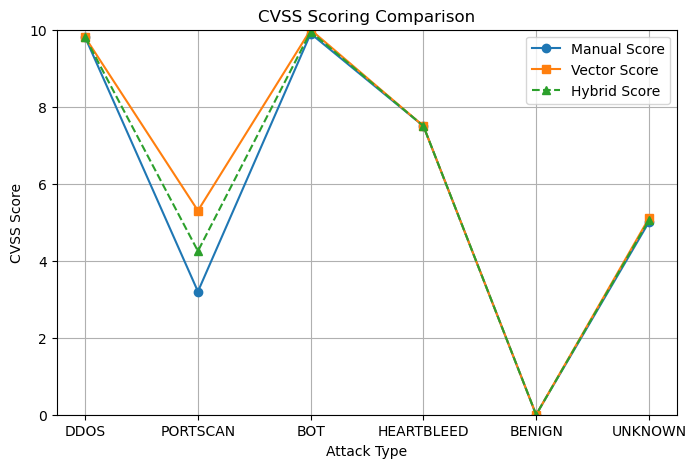

In [17]:
import matplotlib.pyplot as plt

attacks = ["DDOS", "PORTSCAN", "BOT", "HEARTBLEED", "BENIGN", "UNKNOWN"]
manual = [9.8, 3.2, 9.9, 7.5, 0.0, 5.0]
vector = [9.8, 5.3, 10.0, 7.5, 0.0, 5.1]
hybrid = [9.8, 4.25, 9.95, 7.5, 0.0, 5.05]

plt.figure(figsize=(8,5))
plt.plot(attacks, manual, marker='o', label='Manual Score')
plt.plot(attacks, vector, marker='s', label='Vector Score')
plt.plot(attacks, hybrid, marker='^', label='Hybrid Score', linestyle='--')
plt.title("CVSS Scoring Comparison")
plt.xlabel("Attack Type")
plt.ylabel("CVSS Score")
plt.ylim(0, 10)
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import paho.mqtt
print(paho.mqtt.__version__)

2.1.0


In [19]:
# Required installations - run once
!pip install paho-mqtt

import paho.mqtt.client as mqtt
import json

# MQTT Configurations
MQTT_BROKER = "localhost"  # Update with your broker IP if remote
MQTT_PORT = 1883

# Utility functions for MQTT publish/subscribe
def mqtt_publish(topic, message):
    client = mqtt.Client()
    client.connect(MQTT_BROKER, MQTT_PORT, 60)
    client.publish(topic, json.dumps(message))
    client.disconnect()

def mqtt_subscribe(topic, on_message_callback):
    client = mqtt.Client()
    client.connect(MQTT_BROKER, MQTT_PORT, 60)
    client.subscribe(topic)
    client.on_message = on_message_callback
    client.loop_start()
    return client

# Agentic AI refiner function for CVSS decision
def cvss_agentic_refiner(cvss_decision, anomaly_score, context=None):
    if anomaly_score > 0.9 and cvss_decision['Severity'] in ['Low', 'Medium']:
        return {'refined_severity': 'High', 'reason': "Severe anomaly detected overrides low CVSS"}
    elif cvss_decision['Severity'] == 'Critical':
        return {'refined_severity': 'Critical', 'reason': "Highest risk confirmed"}
    return {'refined_severity': cvss_decision['Severity'], 'reason': "No refinement"}

# Example function that simulates your CVSS scoring (replace with your actual function)
def compute_cvss_score(detected_attack):
    # Dummy example output, replace with real scoring logic
    return {'Severity': detected_attack.get('severity', 'Medium'), 'Score': detected_attack.get('score', 5.0)}

# Example usage integrating CVSS, agent refinement, and MQTT communication
def process_attack_event(detected_attack, model_anomaly_score):
    # Step 1: CVSS Scoring
    cvss_result = compute_cvss_score(detected_attack)
    mqtt_publish("cvss/score", cvss_result)
    print("Published CVSS result:", cvss_result)
    
    # Step 2: Agentic AI Refinement based on CVSS and anomaly score
    refined_decision = cvss_agentic_refiner(cvss_result, model_anomaly_score)
    mqtt_publish("refined/decision", refined_decision)
    print("Published refined decision:", refined_decision)
    
    # Optionally: further processing or alerting based on refinement
    
    return refined_decision

# Example MQTT message handlers (for subscribing models/components)
def on_cvss_score(client, userdata, msg):
    cvss_data = json.loads(msg.payload.decode())
    print("Received CVSS score message:", cvss_data)
    # Add logic to trigger refinement or other processing here

def on_refined_decision(client, userdata, msg):
    refined_data = json.loads(msg.payload.decode())
    print("Received refined decision:", refined_data)
    # Add logic to execute automated remediation if desired

# To initiate MQTT subscriptions (call once at start)
cvss_client = mqtt_subscribe("cvss/score", on_cvss_score)
refined_client = mqtt_subscribe("refined/decision", on_refined_decision)

# Simulated attack event for demonstration
detected_attack_example = {'severity': 'Medium', 'score': 5.5, 'vector': 'NETWORK'}
anomaly_score_example = 0.92  # e.g., output from anomaly detection model

# Process the example attack event
final_decision = process_attack_event(detected_attack_example, anomaly_score_example)
print("Final refined decision:", final_decision)


Published CVSS result: {'Severity': 'Medium', 'Score': 5.5}
Received CVSS score message: {'Severity': 'Medium', 'Score': 5.5}
Received refined decision: {'refined_severity': 'High', 'reason': 'Severe anomaly detected overrides low CVSS'}
Published refined decision: {'refined_severity': 'High', 'reason': 'Severe anomaly detected overrides low CVSS'}
Final refined decision: {'refined_severity': 'High', 'reason': 'Severe anomaly detected overrides low CVSS'}



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import json
import time
import logging
import random
import threading
import paho.mqtt.client as mqtt

# --------- Mock Nuclear Plant Control API ---------

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

class MockNuclearPlantAPI:
    def __init__(self):
        self.network_segments_isolated = set()
        self.systems_shutdown = set()

    def _simulate_network_delay(self, min_sec=0.5, max_sec=2):
        delay = random.uniform(min_sec, max_sec)
        logging.info(f"Simulating network delay of {delay:.2f} seconds")
        time.sleep(delay)

    def isolate_network_segment(self, segment_id):
        self._simulate_network_delay()
        if segment_id in self.network_segments_isolated:
            msg = f"Network segment '{segment_id}' is already isolated."
            logging.warning(msg)
            return 400, msg
        self.network_segments_isolated.add(segment_id)
        msg = f"Successfully isolated network segment '{segment_id}'."
        logging.info(msg)
        return 200, msg

    def send_operator_alert(self, message):
        self._simulate_network_delay(0.2, 1)
        logging.info(f"Operator alert sent: {message}")
        return 200, "Alert sent successfully."

    def emergency_shutdown(self, system_id):
        self._simulate_network_delay(1, 3)
        if system_id in self.systems_shutdown:
            msg = f"System '{system_id}' is already shut down."
            logging.warning(msg)
            return 400, msg
        self.systems_shutdown.add(system_id)
        msg = f"Emergency shutdown initiated for system '{system_id}'."
        logging.info(msg)
        return 200, msg


# --------- Self-Healing MQTT Module ---------

MQTT_BROKER = "localhost"
MQTT_PORT = 1883

mock_api = MockNuclearPlantAPI()

def trigger_action(severity, reason):
    if severity == 'Low':
        action = "Log and monitor"
    elif severity == 'Medium':
        status, resp = mock_api.send_operator_alert(f"Medium risk detected: {reason}")
        action = f"Operator alert sent (status {status})"
    elif severity == 'High':
        status, resp = mock_api.isolate_network_segment("segment-123")
        action = f"Network isolated (status {status})"
    elif severity == 'Critical':
        status, resp = mock_api.emergency_shutdown("reactor-1")
        action = f"Emergency shutdown triggered (status {status})"
    else:
        action = "No action"
    logging.info(f"Action triggered: {action}")
    return action

def on_refined_decision(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())
        severity = data.get('refined_severity', 'Low')
        reason = data.get('reason', 'No reason provided')
        logging.info(f"Received refined decision: severity={severity}, reason={reason}")
        action = trigger_action(severity, reason)
        
        # Publish action status to MQTT for audit & monitoring
        status_msg = {'severity': severity, 'action': action, 'reason': reason}
        client.publish("selfhealing/status", json.dumps(status_msg))
    except Exception as e:
        logging.error(f"Error processing refined decision message: {e}")

def on_connect(client, userdata, flags, rc):
    if rc == 0:
        logging.info(f"{client._client_id.decode()} connected to MQTT Broker")
        client.subscribe("refined/decision")
    else:
        logging.error(f"{client._client_id.decode()} failed to connect to MQTT Broker, rc={rc}")

def on_disconnect(client, userdata, rc):
    if rc != 0:
        logging.warning(f"{client._client_id.decode()} disconnected unexpectedly with rc={rc}")
    else:
        logging.info(f"{client._client_id.decode()} disconnected cleanly.")

def on_selfhealing_status(client, userdata, msg):
    try:
        status = json.loads(msg.payload.decode())
        logging.info(f"Self-Healing Status Update: {status}")
    except Exception as e:
        logging.error(f"Error processing self-healing status message: {e}")

def start_self_healing_module():
    client = mqtt.Client(client_id="SelfHealingAgent")
    client.username_pw_set(username="testuser", password="vanitha")
    client.on_connect = on_connect
    client.on_disconnect = on_disconnect
    client.on_message = on_refined_decision
    client.connect(MQTT_BROKER, MQTT_PORT, 60)
    try:
        client.loop_forever()
    except Exception as e:
        logging.error(f"SelfHealingAgent client error: {e}")
    finally:
        client.loop_stop()
        client.disconnect()


def start_status_monitor():
    client = mqtt.Client(client_id="SelfHealingStatusMonitor")
    client.username_pw_set(username="testuser", password="vanitha")
    client.on_connect = on_connect
    client.on_disconnect = on_disconnect
    client.connect(MQTT_BROKER, MQTT_PORT, 60)
    client.subscribe("selfhealing/status")
    client.on_message = on_selfhealing_status
    try:
        client.loop_forever()
    except Exception as e:
        logging.error(f"SelfHealingStatusMonitor client error: {e}")
    finally:
        client.loop_stop()
        client.disconnect()


# --------- Run the modules ---------

if __name__ == "__main__":
    threading.Thread(target=start_self_healing_module, daemon=True).start()
    threading.Thread(target=start_status_monitor, daemon=True).start()

    print("Self-Healing module and status monitor running...")
    while True:
        time.sleep(1)


C:\Users\MY PC\AppData\Local\Temp\ipykernel_17180\2926644848.py:112: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client(client_id="SelfHealingAgent")
C:\Users\MY PC\AppData\Local\Temp\ipykernel_17180\2926644848.py:128: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client(client_id="SelfHealingStatusMonitor")
2025-11-23 16:29:17,499 - INFO - SelfHealingStatusMonitor connected to MQTT Broker
2025-11-23 16:29:17,514 - INFO - SelfHealingAgent connected to MQTT Broker


Self-Healing module and status monitor running...


In [ ]:
import json
import time
import logging
import random
import threading
import paho.mqtt.client as mqtt
import torch
import torch.nn as nn
import torch.optim as optim

# ... [MockNuclearPlantAPI class definition remains here] ...

# --------- Simple PyTorch Model --------
# This is a dummy model to demonstrate the FedProx logic.
# In a real system, this would be your Hybrid Autoencoder (or a classifier head).

class SimpleModel(nn.Module):
    def __init__(self, input_dim=69, output_dim=2): # Assuming input_dim=69 from earlier data prep
        super(SimpleModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, output_dim)

    def forward(self, x):
        # Flatten the (1, 69) input for the FNN model
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Initialize the model and its state
model = SimpleModel()
global_model_weights = model.state_dict()


# --------- FedProx Training Function --------
# This function simulates local training with the FedProx regularization term.

def train_with_fedprox(data, model, global_state, epochs=1, mu=0.01, lr=0.001):
    """Simulates local training with the FedProx algorithm."""
    model.load_state_dict(global_state)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    # Using MSE Loss as a proxy for the Autoencoder's reconstruction loss, but
    # CrossEntropy is more typical for a classifier (which is what feedback is for).
    loss_fn = nn.CrossEntropyLoss() 
    
    # Simple fixed features/labels conversion for demonstration (must be adapted)
    def prep_data(data_list):
        features = torch.stack([d['features'] for d in data_list])
        labels = torch.tensor([d['label'] for d in data_list], dtype=torch.long)
        return features, labels
    
    features, labels = prep_data(data)
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(features)
        loss = loss_fn(output, labels)

        # FedProx proximal term (L2 norm between local and global weights)
        prox_reg = 0
        for param, global_param_tensor in zip(model.parameters(), global_state.values()):
            # Ensure global_param is on the same device and is float
            global_param = global_param_tensor.float().to(param.device)
            prox_reg += ((param - global_param) ** 2).sum()
            
        loss += (mu / 2) * prox_reg

        loss.backward()
        optimizer.step()
        
    avg_loss = loss.item() / len(data)
    logging.info(f"FedProx training epoch {epoch+1}, avg loss: {avg_loss:.4f}")

    return model.state_dict(), avg_loss


# --------- Feedback Collection and Training Loop --------

local_feedback_log = []
# Set interval to 600 seconds (10 minutes) for realistic training frequency
TRAIN_INTERVAL = 600  
# Use a simple mock API instance
mock_api = MockNuclearPlantAPI()

# Placeholder for feature extraction (must match your model's expected input shape)
def extract_features_from_feedback(feedback):
    # Get 69 features (matching your X_supervised.shape[2]) and binary label
    severity_map = {'Low': 0, 'Medium': 0, 'High': 1, 'Critical': 1, 'None': 0}
    # Create a tensor of 69 random floats (replace with actual captured network features)
    features = torch.tensor([random.random() for _ in range(69)], dtype=torch.float32) 
    label = severity_map.get(feedback['severity'], 0)
    return {'features': features, 'label': label}


def trigger_action(severity, reason):
    global local_feedback_log
    # ... [Action logic remains unchanged] ...
    if severity == 'Low':
        action = "Log and monitor"
    elif severity == 'Medium':
        status, resp = mock_api.send_operator_alert(f"Medium risk detected: {reason}")
        action = f"Operator alert sent (status {status})"
    elif severity == 'High':
        status, resp = mock_api.isolate_network_segment("segment-123")
        action = f"Network isolated (status {status})"
    elif severity == 'Critical':
        status, resp = mock_api.emergency_shutdown("reactor-1")
        action = f"Emergency shutdown triggered (status {status})"
    else:
        action = "No action"
        
    logging.info(f"Action triggered: {action}")

    # **CRITICAL FEEDBACK STEP:** Collect feedback data for training
    feedback = {
        'timestamp': time.time(),
        'severity': severity,
        'reason': reason,
        'action': action
    }
    local_feedback_log.append(extract_features_from_feedback(feedback))

    return action

# The on_refined_decision function is updated to use the new trigger_action
def on_refined_decision(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())
        severity = data.get('refined_severity', 'Low')
        reason = data.get('reason', 'No reason provided')
        logging.info(f"Received refined decision: severity={severity}, reason={reason}")
        action = trigger_action(severity, reason)
        
        status_msg = {'severity': severity, 'action': action, 'reason': reason}
        client.publish("selfhealing/status", json.dumps(status_msg))
    except Exception as e:
        logging.error(f"Error processing refined decision message: {e}")


def periodic_train_and_sync():
    global global_model_weights, local_feedback_log
    while True:
        # Wait for the training interval to pass
        time.sleep(TRAIN_INTERVAL)
        
        logging.info("Starting periodic FedProx training round ...")
        
        # Minimum samples required for training (e.g., 5-10)
        if len(local_feedback_log) < 5:  
            logging.info(f"Only {len(local_feedback_log)} feedback samples collected. Skipping this round.")
            continue

        # Copy and clear log before training
        data_for_training = local_feedback_log.copy()
        local_feedback_log.clear()

        try:
            # Train locally using FedProx
            new_weights, avg_loss = train_with_fedprox(data_for_training, model, global_model_weights, epochs=1)

            # Simulate Aggregation: Average the new local weights with the existing global weights
            # In a true FL setup, this would involve sending weights to a central server.
            logging.info("Simulating weight aggregation and updating global model state.")
            for key in global_model_weights.keys():
                global_model_weights[key] = (global_model_weights[key] + new_weights[key]) / 2

            logging.info(f"FedProx training round completed with new global weights (Avg Loss: {avg_loss:.4f}).")

        except Exception as e:
            logging.error(f"FedProx training failed: {e}")


# --- MQTT start functions (start_self_healing_module, start_status_monitor) remain unchanged ---

# --------- Main Execution with FedProx Thread --------

if __name__ == "__main__":
    # Ensure the Mock API is initialized with the current global mock_api object
    
    # Start MQTT self-healing modules on threads
    threading.Thread(target=start_self_healing_module, daemon=True).start()
    threading.Thread(target=start_status_monitor, daemon=True).start()

    # **NEW THREAD:** Start periodic FedProx training background loop
    threading.Thread(target=periodic_train_and_sync, daemon=True).start()

    print("Self-Healing module, status monitor, and FedProx feedback loop running...")
    while True:
        time.sleep(1)